In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
from pathlib import Path

TARGET_CRS = "EPSG:5070"

In [70]:
folder = Path("./census")

IllinoisCensus = {}

for file in folder.iterdir():
    if file.is_file() and file.suffix.lower() == ".csv":
        IllinoisCensus[file.name] = pd.read_csv(file)

In [63]:
ILTracts2020 = gpd.read_file('./maps/raw/historical_census_tracts_by_state/tracts_2022/Illinois_tl_2022_17_tract/tl_2022_17_tract.shp').to_crs(TARGET_CRS)
ChicagoCommunityAreas = gpd.read_file("./maps/raw/Chicago/ChicagoCommunityAreas.geojson").to_crs(TARGET_CRS)

ChicagoArea = gpd.read_file("./maps/raw/Chicago/ChicagoArea.geojson").to_crs(TARGET_CRS)

USAirports = gpd.read_file("./maps/raw/USAirports.json").to_crs(TARGET_CRS)

ChicagoAirports = USAirports[(
    (USAirports['icao'].isin(['KORD', 'KMDW']))
)]
ChicagoParks = gpd.read_file("./maps/raw/Chicago/CPD_Parks_20250819.geojson").to_crs(TARGET_CRS)

In [64]:
ILTracts2000_InChicago = ILTracts2020.clip(ChicagoArea)

In [65]:
ChicagoCommunityAreasClipped = gpd.overlay(
    ChicagoCommunityAreas,
    ChicagoAirports,
    how="difference"
)

ChicagoCommunityAreasClipped = gpd.overlay(
    ChicagoCommunityAreas,
    ChicagoParks,
    how="difference"
)

In [66]:
# Calculate tract/community-area polygon overlaps
overlaps = gpd.overlay(
    ILTracts2000_InChicago,
    ChicagoCommunityAreasClipped[
        ["area_numbe", "community", "geometry"]
    ],
    how="intersection",
)

# Calculate overlap area
overlaps["overlap_area"] = overlaps.geometry.area

# Keep the community area with the largest overlap per tract
largest_overlap = (
    overlaps
    .sort_values("overlap_area", ascending=False)
    .drop_duplicates(subset="GEOID")
)

# Attach the classification to the original tract polygons
tracts_classified = ILTracts2000_InChicago.merge(
    largest_overlap[
        ["GEOID", "community"]
    ],
    on="GEOID",
    how="left",
)

c:\Users\Wayne\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\geopandas\tools\overlay.py:358: UserWarning: `keep_geom_type=True` in overlay resulted in 22 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)


In [74]:
tracts_classified.to_file("./maps/raw/Chicago/ChicagoCommunityAreaCensusTracts2020.geojson")

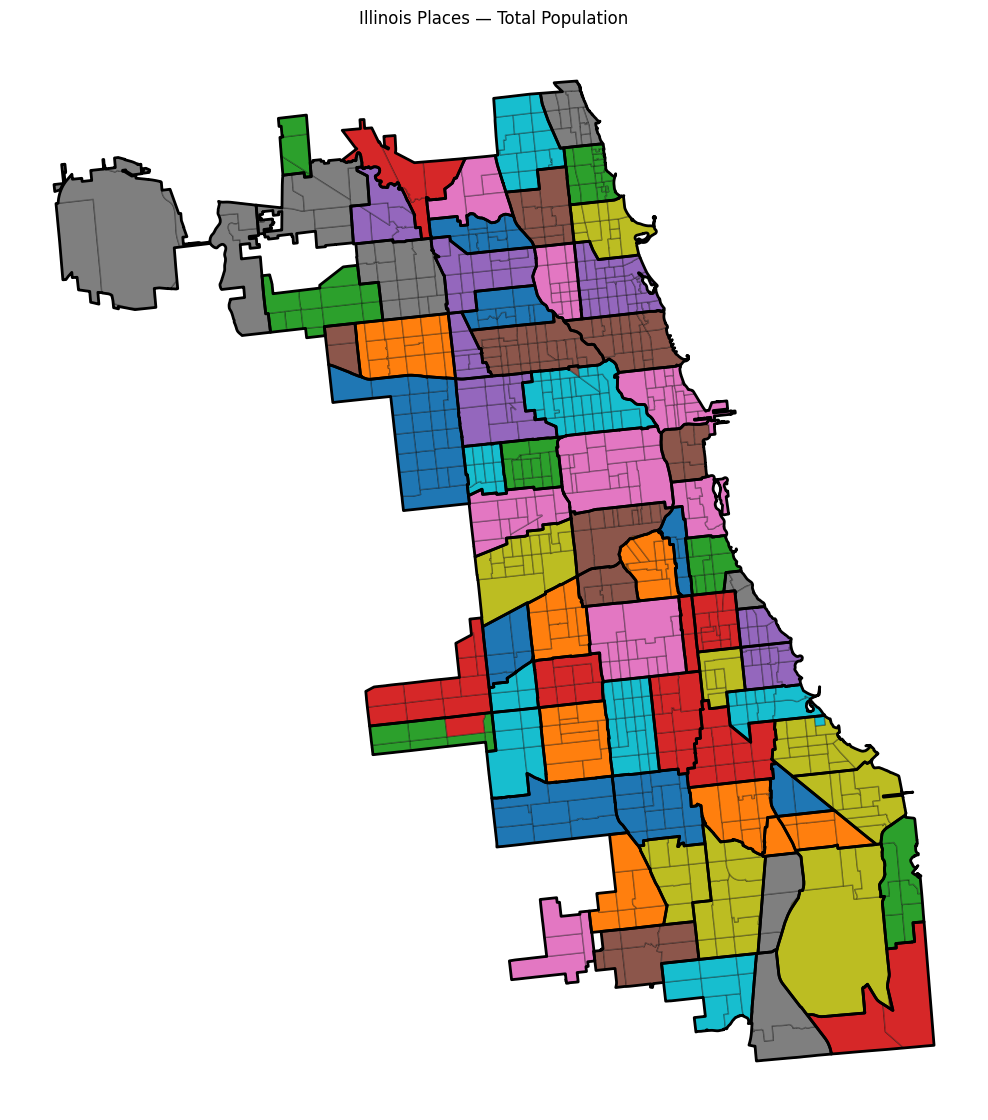

In [68]:
fig, ax = plt.subplots(figsize=(14, 14))

tracts_classified.plot(
    ax=ax,
    column="community",
    categorical=True,
    legend=False,
    edgecolor="#00000050",
    linewidth=1,
)

ChicagoCommunityAreas.plot(
    ax=ax,
    edgecolor='#000000',
    color='#ffffff00',
    linewidth=2
)


ax.set_axis_off()
ax.set_title("Illinois Places — Total Population")
plt.show()


In [72]:
IllinoisCensus['IL_2020_ACS5_tract_data.csv']

,NAME_x,B02001_001E,B03002_003E,B03002_004E,B03002_012E,B03002_005E,B03002_006E,B03002_007E,B15003_020E,B15003_021E,...,B01001_041E,B01001_042E,B01001_043E,B01001_044E,B01001_045E,B01001_046E,B01001_047E,B01001_048E,B01001_049E,GEOID
0,"Census Tract 1, Adams County, Illinois",4607,4179,285,0,0,46,0,572,359,...,162,73,88,166,66,171,142,77,186,17001000100
1,"Census Tract 2.01, Adams County, Illinois",2003,1790,131,32,0,7,0,166,138,...,63,31,51,23,67,60,22,10,31,17001000201
2,"Census Tract 2.02, Adams County, Illinois",2391,2013,245,16,15,2,0,187,189,...,105,12,22,27,33,40,25,20,0,17001000202
3,"Census Tract 4, Adams County, Illinois",3314,2560,454,25,0,35,0,216,133,...,169,52,25,13,66,46,50,28,91,17001000400
4,"Census Tract 5, Adams County, Illinois",2154,1798,176,104,11,25,0,229,69,...,79,29,68,9,37,52,54,31,73,17001000500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3260,"Census Tract 305.01, Woodford County, Illinois",7768,7456,51,77,0,68,0,371,731,...,277,48,179,58,82,286,160,49,37,17203030501
3261,"Census Tract 305.02, Woodford County, Illinois",2616,2545,1,45,5,9,0,290,224,...,111,85,63,16,63,99,43,16,16,17203030502
3262,"Census Tract 306.01, Woodford County, Illinois",6374,5850,94,294,0,8,0,571,339,...,129,102,138,106,115,57,124,105,324,17203030601
3263,"Census Tract 306.02, Woodford County, Illinois",4001,3790,0,10,1,28,0,290,363,...,178,88,87,19,32,63,44,77,18,17203030602
